In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys,os
path_to_add = os.path.abspath('../')
print('path_to_add:',path_to_add)
sys.path.append(path_to_add)
from func_fix_curvefit_params import *
from general_utility_functions import *


path_to_add: /Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=14) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

color_plots = 'tab:red' # or tab:red

In [3]:
root_folder = '../../data/playfight_data/'

In [4]:
curvefit_ses1 = pd.read_csv(f'{root_folder}/curve_fit_aggressiveness_ses1_linear/all_params_1k_fight_linear.csv')#merged_apr_ses1.csv')#('../data/ses1_data/curve_fit_rmse/all_params_1k.csv')
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:]# has bad subs

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
14,26014.0,0.000000e+00,0.303568,-40.518924,inf,0.000000,0.352286,0.352286,0.647714,0.0,0.0,False
55,26060.0,7.984686e-02,0.302446,-38.842548,-5.144827,0.041429,NaN,0.286857,0.754571,1.0,1.0,True
70,26079.0,3.750000e-01,0.276642,-18.983900,-0.388889,0.450000,0.675000,0.675000,-0.125000,0.0,0.0,False
150,26165.0,3.891542e-01,0.232675,-33.504478,-1.486093,0.164357,NaN,0.255750,0.908607,1.0,1.0,True
175,26195.0,-2.220446e-16,0.309204,-30.304180,-inf,0.000000,NaN,0.379444,0.620556,1.0,1.0,True
257,26285.0,2.157118e-02,0.348544,-42.059395,-0.302487,0.016595,NaN,0.494980,0.521615,1.0,1.0,True
308,26338.0,5.491162e-01,0.228676,-37.415560,-1.493350,0.171857,NaN,0.243357,0.928500,1.0,1.0,True


In [5]:
curvefit_ses1 = fix_obj_center(curvefit_ses1)
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:] # bad subs bc of obj_center removed. rest will be removed with neg amplitudes

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
55,26060.0,7.984686e-02,0.302446,-38.842548,NaN,0.041429,NaN,0.286857,0.754571,1.0,1.0,True
150,26165.0,3.891542e-01,0.232675,-33.504478,NaN,0.164357,NaN,0.255750,0.908607,1.0,1.0,True
173,26193.0,9.428737e-01,0.083005,-30.885994,NaN,0.962103,NaN,0.962203,0.999900,1.0,1.0,True
175,26195.0,-2.220446e-16,0.309204,-30.304180,NaN,0.000000,NaN,0.379444,0.620556,1.0,1.0,True
178,26198.0,2.821719e-01,0.280972,-39.169052,NaN,0.086143,NaN,0.594452,0.491690,1.0,1.0,True
227,26253.0,5.391453e-01,0.254507,-36.419557,NaN,0.180857,NaN,0.619571,0.561286,1.0,1.0,True
257,26285.0,2.157118e-02,0.348544,-42.059395,NaN,0.016595,NaN,0.494980,0.521615,1.0,1.0,True
308,26338.0,5.491162e-01,0.228676,-37.415560,NaN,0.171857,NaN,0.243357,0.928500,1.0,1.0,True


In [6]:
curvefit_ses2 =  pd.read_csv(f'{root_folder}/curve_fit_aggressiveness_ses2_linear/all_params_1k_fight_linear.csv')
bad_rows = (np.isnan(curvefit_ses2['obj_center'])) | \
      (np.isinf(curvefit_ses2['obj_center'])) | \
    (curvefit_ses2['obj_center']<0)
curvefit_ses2.loc[bad_rows,:] # has bad rows

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
46,26067.0,2.844281e-01,0.290743,-54.685573,-0.204413,0.028595,NaN,0.494155,0.534440,1.0,1.0,True
128,26171.0,3.594371e-01,0.256310,-38.090061,-0.351003,0.111167,0.53902,0.539020,0.349813,0.0,0.0,False
136,26182.0,-2.220446e-16,0.305028,-26.694628,inf,0.000000,NaN,0.500857,0.499143,1.0,1.0,True


In [7]:
curvefit_ses1.shape, curvefit_ses2.shape

((319, 12), (269, 12))

In [8]:
curvefit_ses2.loc[curvefit_ses2['bias_xmax']<0,:].shape # has rows with neg bias_xmax

(8, 12)

In [9]:
curvefit_ses2 = fix_obj_center(curvefit_ses2)
bad_rows = (np.isnan(curvefit_ses2['obj_center'])) | \
      (np.isinf(curvefit_ses2['obj_center'])) | \
    (curvefit_ses2['obj_center']<0)
curvefit_ses2.loc[bad_rows,:] # bad subs bc of obj_center removed

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped
46,26067.0,2.844281e-01,0.290743,-54.685573,NaN,0.028595,NaN,0.494155,0.534440,1.0,1.0,True
126,26169.0,3.977302e-01,0.258664,-34.969223,NaN,0.150714,NaN,0.570595,0.580119,1.0,1.0,True
136,26182.0,-2.220446e-16,0.305028,-26.694628,NaN,0.000000,NaN,0.500857,0.499143,1.0,1.0,True
145,26193.0,8.561438e-01,0.133840,-27.144130,NaN,0.791238,NaN,0.877714,0.913524,1.0,1.0,True
199,26263.0,8.543286e-01,0.118509,-37.162888,NaN,0.384000,NaN,0.592714,0.791286,1.0,1.0,True


In [10]:
curvefit_ses1 = add_new_params(curvefit_ses1)
curvefit_ses1.loc[curvefit_ses1['range']<0,:] # has neg range rows

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
55,26060.0,0.079847,0.302446,-38.842548,NaN,0.041429,NaN,0.286857,0.754571,1.0,1.0,True,-0.041429,0.275446
150,26165.0,0.389154,0.232675,-33.504478,NaN,0.164357,NaN,0.255750,0.908607,1.0,1.0,True,-0.164357,0.219649
173,26193.0,0.942874,0.083005,-30.885994,NaN,0.962103,NaN,0.962203,0.999900,1.0,1.0,True,-0.962103,0.490394
178,26198.0,0.282172,0.280972,-39.169052,NaN,0.086143,NaN,0.594452,0.491690,1.0,1.0,True,-0.086143,0.547306
227,26253.0,0.539145,0.254507,-36.419557,NaN,0.180857,NaN,0.619571,0.561286,1.0,1.0,True,-0.180857,0.524679
257,26285.0,0.021571,0.348544,-42.059395,NaN,0.016595,NaN,0.494980,0.521615,1.0,1.0,True,-0.016595,0.486900
308,26338.0,0.549116,0.228676,-37.415560,NaN,0.171857,NaN,0.243357,0.928500,1.0,1.0,True,-0.171857,0.207668


In [11]:
curvefit_ses1.loc[curvefit_ses1['range']==0,:] # has neg range rows

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
14,26014.0,0.000000e+00,0.303568,-40.518924,1.0,0.0,0.352286,0.352286,0.647714,0.0,0.0,False,0.0,0.352286
175,26195.0,-2.220446e-16,0.309204,-30.304180,NaN,0.0,NaN,0.379444,0.620556,1.0,1.0,True,0.0,0.379444


In [12]:
curvefit_ses1.shape, curvefit_ses2.shape

((319, 14), (269, 12))

In [13]:
curvefit_ses1 = curvefit_ses1.loc[curvefit_ses1['range']>0,:] # remove negative amplitudes
curvefit_ses1.loc[curvefit_ses1['range']<0,:] 

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [16]:
bad_rows = (np.isnan(curvefit_ses1['obj_center'])) | \
      (np.isinf(curvefit_ses1['obj_center'])) | \
    (curvefit_ses1['obj_center']<0)
curvefit_ses1.loc[bad_rows,:]# all bad subs removed

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [17]:
curvefit_ses1.loc[curvefit_ses1['bias_xmax']<0,:].shape # neg bias rows removed

(0, 14)

In [18]:
curvefit_ses2 = add_new_params(curvefit_ses2)
curvefit_ses2.loc[curvefit_ses2['range']<0,:]

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
46,26067.0,0.284428,0.290743,-54.685573,NaN,0.028595,NaN,0.494155,0.534440,1.0,1.0,True,-0.028595,0.480417
126,26169.0,0.397730,0.258664,-34.969223,NaN,0.150714,NaN,0.570595,0.580119,1.0,1.0,True,-0.150714,0.495862
145,26193.0,0.856144,0.133840,-27.144130,NaN,0.791238,NaN,0.877714,0.913524,1.0,1.0,True,-0.791238,0.490004
199,26263.0,0.854329,0.118509,-37.162888,NaN,0.384000,NaN,0.592714,0.791286,1.0,1.0,True,-0.384000,0.428262


In [20]:
curvefit_ses1.shape, curvefit_ses2.shape

((310, 14), (269, 14))

In [21]:
curvefit_ses2 = curvefit_ses2.loc[curvefit_ses2['range']>0,:] # remove negative amplitudes
curvefit_ses2.loc[curvefit_ses2['range']<0,:]

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias


In [22]:
bad_rows = (np.isnan(curvefit_ses2['obj_center'])) | \
      (np.isinf(curvefit_ses2['obj_center'])) | \
    (curvefit_ses2['obj_center']<0)
curvefit_ses2.loc[bad_rows,:]# all bad subs removed

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
136,26182.0,-2.220446e-16,0.305028,-26.694628,NaN,0.0,NaN,0.500857,0.499143,1.0,1.0,True,5.551115e-17,0.500857


In [23]:
curvefit_ses2.loc[curvefit_ses2['bias_xmax']<0,:].shape # neg bias rows removed

(0, 14)

In [24]:
curvefit_ses1.rename(columns={'obj_center':'PSE'},inplace=True)
curvefit_ses2.rename(columns={'obj_center':'PSE'},inplace=True)

In [26]:
return_minmax(curvefit_ses1,'PSE')
return_minmax(curvefit_ses1,'range')
return_minmax(curvefit_ses1,'bias')

return_minmax(curvefit_ses2,'PSE')
return_minmax(curvefit_ses2,'range')
return_minmax(curvefit_ses2,'bias')

PSE: min=0.00, max=1.00
range: min=0.00, max=1.00
bias: min=0.00, max=1.00
PSE: min=0.00, max=1.00
range: min=0.00, max=0.99
bias: min=0.00, max=1.00


In [27]:
curvefit_ses1.shape, curvefit_ses2.shape

((310, 14), (265, 14))

In [28]:
cmap = 'BrBG'#'RdBu_r'

In [29]:
cols = ['range','bias'] #['PSE','slope','bias']

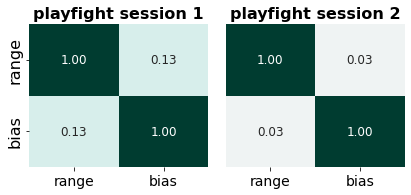

In [30]:
fig,axs = plt.subplots(nrows=1,ncols = 2, figsize=(6,3))

ax = axs[0]
sns.heatmap(curvefit_ses1.loc[:,cols].corr(),vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 12})
ax.set_title('playfight session 1',fontweight='bold')

ax = axs[1]
sns.heatmap(curvefit_ses2.loc[:,cols].corr(),vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 12})
ax.set_title('playfight session 2',fontweight='bold')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('../../results/playfight/curvefit_2params/curvefit_covar_allcols_playfight.png', dpi=300, bbox_inches='tight')

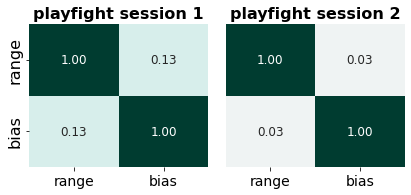

In [31]:
fig,axs = plt.subplots(nrows=1,ncols = 2, figsize=(6,3))

ax = axs[0]
sns.heatmap(curvefit_ses1.loc[:,cols].corr(),vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 12})
ax.set_title('playfight session 1',fontweight='bold')

ax = axs[1]
sns.heatmap(curvefit_ses2.loc[:,cols].corr(),vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 12})
ax.set_title('playfight session 2',fontweight='bold')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('../../results/playfight/curvefit_2params/curvefit_covar_allcols_playfight.png', dpi=300, bbox_inches='tight')

# merge them and plot ICC

In [32]:
from general_utility_functions import *
from scipy import stats

In [33]:
bothsess = curvefit_ses1.loc[:,['subID']+cols].merge(curvefit_ses2.loc[:,['subID']+cols],how='inner',on='subID',suffixes = ['_ses1','_ses2'])
bothsess

,subID,range_ses1,bias_ses1,range_ses2,bias_ses2
0,26000.0,0.704565,0.000338,0.477381,0.157191
1,26001.0,0.386857,0.440691,0.521357,0.495225
2,26003.0,0.999900,1.000000,0.981000,1.000000
3,26004.0,0.579214,0.463334,0.214714,0.418683
4,26005.0,0.570000,0.605648,0.803334,0.000508
...,...,...,...,...,...
248,26343.0,0.625500,0.329868,0.676286,0.348191
249,26344.0,0.824037,0.000568,0.792257,0.000481
250,26346.0,0.609643,0.482434,0.523714,0.551590
251,26347.0,0.235905,0.399892,0.282476,0.410760


# ICC

In [35]:
np.where(np.isnan(bothsess))

(array([], dtype=int64), array([], dtype=int64))

In [36]:
import pingouin as pg

In [37]:
bothsess_long = curvefit_ses1.merge(curvefit_ses2,how='inner',on='subID',suffixes = ['_ses1','_ses2'])

curvefit_ses1['sesID'] = 'ses_1'
curvefit_ses2['sesID'] = 'ses_2'
# Identify common subjects across both sessions
common_subjects = set(curvefit_ses2['subID']).intersection(curvefit_ses2['subID'])

# Filter dataframes to keep only common subjects
curvefit_ses1 = curvefit_ses1[curvefit_ses1['subID'].isin(common_subjects)]
curvefit_ses2 = curvefit_ses2[curvefit_ses2['subID'].isin(common_subjects)]

# Concatenate filtered dataframes vertically
bothsess_long = pd.concat([curvefit_ses1, curvefit_ses2], ignore_index=True)
bothsess_long.head()

/Users/f0053cz/anaconda3/envs/py37/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
/Users/f0053cz/anaconda3/envs/py37/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.0, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


,subID,r_squared,nrmse,aic,PSE,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias,sesID
0,26000.0,0.940328,0.089873,-35.484797,0.709516,0.704565,0.000100,0.000100,0.295335,0.0,0.0,False,0.704565,0.000338,ses_1
1,26001.0,0.823224,0.147384,-35.444795,0.594001,0.386857,0.270206,0.270206,0.342937,0.0,0.0,False,0.386857,0.440691,ses_1
2,26003.0,0.915302,0.111619,-26.697277,0.499900,1.000000,0.000100,0.000100,0.000000,0.0,0.0,False,0.999900,1.000000,ses_1
3,26004.0,0.972040,0.051894,-43.866039,0.526637,0.579214,0.194964,0.194964,0.225821,0.0,0.0,False,0.579214,0.463334,ses_1
4,26005.0,0.936739,0.089287,-38.116158,0.420301,0.570000,0.260429,0.260429,0.169571,0.0,0.0,False,0.570000,0.605648,ses_1


In [38]:
colnames = ['slope','bias','PSE','range','lb','ub']

In [39]:
save_icc = {}
# Calculate ICC for each parameter
for param in colnames:
    print(param)
    if param == 'subj_center':
        param = 'center'
    elif param == 'lb':
        param = 'bias_xmin'
    elif param == 'ub':
        param = 'bias_xmax'
    icc = pg.intraclass_corr(data=bothsess_long, targets = 'subID', raters = 'sesID', ratings = param, nan_policy='omit')
#     print(icc)
    # printing results for ICC 1
    print(f"ICC2 for {param}: {icc.iloc[1, 2]:.3f},ICC2k for {param}: {icc.iloc[4, 2]:.3f}")
    save_icc[param] = [icc.iloc[1, 2], icc.iloc[1, 6]]

slope
ICC2 for slope: 0.649,ICC2k for slope: 0.787
bias
ICC2 for bias: 0.514,ICC2k for bias: 0.679
PSE
ICC2 for PSE: 0.591,ICC2k for PSE: 0.743
range
ICC2 for range: 0.650,ICC2k for range: 0.788
lb
ICC2 for bias_xmin: 0.565,ICC2k for bias_xmin: 0.722
ub
ICC2 for bias_xmax: 0.680,ICC2k for bias_xmax: 0.809


# PLots

In [40]:
def get_p_markers(p):
    if p < .001:
        return "***"
    elif p < .01:
        return f"**"
    elif p < .05:
        return f"*"

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

color_plots = 'tab:red' # or tab:red

In [42]:
ticks_all = {'PSE':[0,0.3,0.6],'range':[0,0.5,1],'bias':[0,0.5,1]}

In [43]:
save_icc["lb"] = save_icc.pop("bias_xmin")
save_icc["ub"] = save_icc.pop("bias_xmax")
save_icc

{'slope': [0.649182973682564, 1.2034496141149726e-32],
 'bias': [0.5144425369585333, 3.9207709890056123e-19],
 'PSE': [0.5912971143933625, 1.79196580792107e-25],
 'range': [0.6497762964591237, 1.0392243083336879e-32],
 'lb': [0.5650094482930741, 1.2566327362097768e-23],
 'ub': [0.6799265933097655, 3.3332406023946165e-36]}

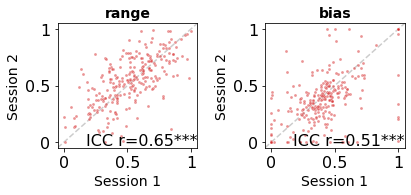

In [44]:
fig, axs = plt.subplots(nrows=1, ncols=len(cols), figsize=(3*len(cols),3))  # Adjusting subplot size to make plots square
for i, item in enumerate(cols):
    ax = axs[i] #axs[i]
    sns.scatterplot(data=bothsess, x=item + '_ses1', y=item + '_ses2', ax=ax, color = 'tab:red',alpha=0.5, marker = '.')
    # ax.set_aspect('equal')  # Ensures same scale on x and y axes
    # Adding a diagonal line from the minimum to maximum values
    limits = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(limits, limits, 'k--', zorder=0, alpha = .2)  # 'k--' specifies a black dotted line
    ax.set_xlim(limits)
    ax.set_ylim(limits)

    ticks = ticks_all[item] #np.arange(limits[0],limits[1]*1.01,(limits[1]-limits[0])/3)
    ticklabels = []
    for t in ticks:
        ticklabels.append(str(t))

    ax.set_xticks(ticks,ticklabels)
    ax.set_yticks(ticks,ticklabels)

    
    x,y =  bothsess[item + '_ses1'],bothsess[item + '_ses2']
    rows = ~(np.isnan(x)) & ~(np.isnan(y)) & ~(np.isinf(x)) & ~(np.isinf(y))
    x = x[rows]
    y = y[rows]
    r_p,p_p = stats.pearsonr(x,y)
    r_s,p_s = stats.spearmanr(x,y)
    ax.annotate(f'ICC r={save_icc[item][0]:.2f}{get_p_markers(save_icc[item][1])}', xy = (1,0),va='bottom',ha='right',xycoords='axes fraction')
    ax.set_title(item, fontweight='bold',fontsize=14) #item,fontweight='bold')
    
    ax.set_xlabel('Session 1',fontsize=14)
    ax.set_ylabel('Session 2',fontsize=14)

plt.tight_layout()
plt.savefig('../../results/playfight/ICC_playfight.png',dpi=300,bbox_inches='tight')

# supp rows

In [46]:
curvefit_ses1_extra = curvefit_ses1.drop(columns=['bias_lower','bias_upper']).rename(columns={'bias_xmin':'lb','bias_xmax':'ub'})
curvefit_ses2_extra = curvefit_ses2.drop(columns=['bias_lower','bias_upper']).rename(columns={'bias_xmin':'lb','bias_xmax':'ub'})

In [47]:
curvefit_ses1_extra.columns

Index(['subID', 'r_squared', 'nrmse', 'aic', 'PSE', 'slope', 'intercept', 'lb',
       'ub', 'flipped', 'range', 'bias', 'sesID'],
      dtype='object')

In [48]:
supp_cols = ['PSE','slope','lb','ub']#,'aic']

In [49]:
bothsess_extra = curvefit_ses1_extra.loc[:,['subID']+supp_cols].merge(curvefit_ses2_extra.loc[:,['subID']+supp_cols],how='inner',on='subID',suffixes = ['_ses1','_ses2'])
bothsess_extra

,subID,PSE_ses1,slope_ses1,lb_ses1,ub_ses1,PSE_ses2,slope_ses2,lb_ses2,ub_ses2
0,26000.0,0.709516,0.704565,0.000100,0.295335,0.875295,0.477381,0.082151,0.440468
1,26001.0,0.594001,0.386857,0.270206,0.342937,0.504384,0.521357,0.237036,0.241607
2,26003.0,0.499900,1.000000,0.000100,0.000000,0.481000,1.000000,0.019000,0.000000
3,26004.0,0.526637,0.579214,0.194964,0.225821,0.797405,0.214714,0.328786,0.456500
4,26005.0,0.420301,0.570000,0.260429,0.169571,0.622282,0.803334,0.000100,0.196566
...,...,...,...,...,...,...,...,...,...
248,26343.0,0.601861,0.625500,0.123536,0.250964,0.572666,0.676286,0.112714,0.211000
249,26344.0,0.606647,0.824037,0.000100,0.175863,0.630982,0.792257,0.000100,0.207643
250,26346.0,0.511248,0.609643,0.188321,0.202036,0.453082,0.523714,0.262714,0.213571
251,26347.0,0.824250,0.235905,0.305556,0.458540,0.726680,0.282476,0.294730,0.422794


In [50]:
save_icc

{'slope': [0.649182973682564, 1.2034496141149726e-32],
 'bias': [0.5144425369585333, 3.9207709890056123e-19],
 'PSE': [0.5912971143933625, 1.79196580792107e-25],
 'range': [0.6497762964591237, 1.0392243083336879e-32],
 'lb': [0.5650094482930741, 1.2566327362097768e-23],
 'ub': [0.6799265933097655, 3.3332406023946165e-36]}

In [51]:
ticks_all = {'PSE':[0,0.5,1],'slope':[0,0.5,1],'lb':[0,0.35,0.7],'ub':[0,0.45,0.9]}

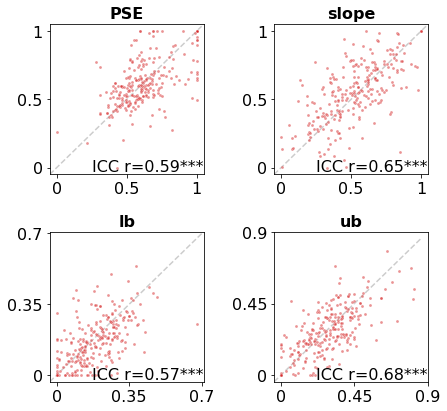

In [52]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(3.25*int(len(supp_cols)/2),3*int(len(supp_cols)/2)))  # Adjusting subplot size to make plots square
for i, item in enumerate(supp_cols):
    r = int(np.floor(i/2))
    c = i%2
    ax = axs[r,c]
    sns.scatterplot(data=bothsess_extra, x=item + '_ses1', y=item + '_ses2', ax=ax, color = 'tab:red',alpha=0.5, marker = '.')
    # Adding a diagonal line from the minimum to maximum values
    limits = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(limits, limits, 'k--', zorder=0, alpha = .2)  # 'k--' specifies a black dotted line
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ticks = ticks_all[item] #np.arange(limits[0],limits[1]*1.01,(limits[1]-limits[0])/3)
    ticklabels = []
    for t in ticks:
        ticklabels.append(str(t))
    ax.set_xticks(ticks,ticklabels)
    ax.set_yticks(ticks,ticklabels)
    x,y =  bothsess_extra[item + '_ses1'],bothsess_extra[item + '_ses2']
    rows = ~(np.isnan(x)) & ~(np.isnan(y)) & ~(np.isinf(x)) & ~(np.isinf(y))
    x = x[rows]
    y = y[rows]
    ax.annotate(f'ICC r={save_icc[item][0]:.2f}{get_p_markers(save_icc[item][1])}', xy = (1,0),va='bottom',ha='right',xycoords='axes fraction')
    ax.set_title(item, fontweight='bold',fontsize=16) #item,fontweight='bold')
    
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../../results/playfight/ICC_playfight_extra.png',dpi=300,bbox_inches='tight')

In [53]:
curvefit_ses1.rename(columns={'bias_xmin':'lb','bias_xmax':'ub'},inplace=True)
curvefit_ses2.rename(columns={'bias_xmin':'lb','bias_xmax':'ub'},inplace=True)

/Users/f0053cz/anaconda3/envs/py37/lib/python3.7/site-packages/pandas/core/frame.py:5047: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [54]:
cols_pf = ['range','bias','PSE','slope','lb','ub']#, \
    # 'slope'] # slope correlates fully with amplitude

In [55]:
import matplotlib.colors as mcolors

In [56]:
cmap = 'BrBG'#'RdBu_r'

/Users/f0053cz/anaconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


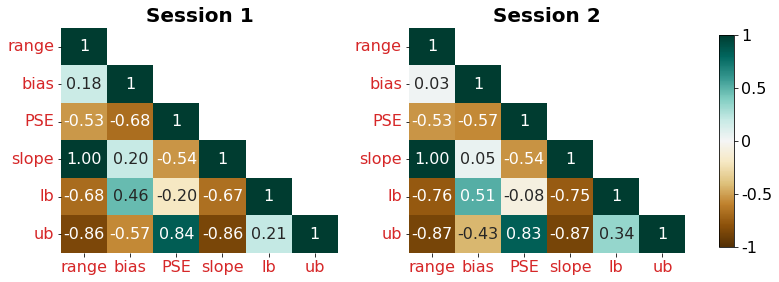

In [58]:
fig,axs = plt.subplots(nrows=1,ncols = 2, figsize=(11,4.2))#(12*5/7,5*5/7))

mask = np.triu(np.ones((len(cols_pf),len(cols_pf)), dtype=bool),k=1)


ax = axs[0]
r_all = curvefit_ses1.loc[:,cols_pf].corr().values
annot = np.array([[f"{val:.2f}" if val <.999 else "1" for val in row] for row in r_all])
sns.heatmap(r_all,vmin=-1,vmax=1,annot=annot,cbar=False,mask=mask,cmap=cmap,ax=ax, fmt = '',annot_kws={"size": 16})
# sns.heatmap(curvefit_ses1.loc[:,cols_pf].corr(),mask=mask,vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 16*5/7})
ax.set_title('Session 1',fontweight='bold', fontsize=20)
ax.set_xticklabels(cols_pf,rotation=0, fontsize=16, color = 'tab:red')
ax.set_yticklabels(cols_pf,rotation=0, fontsize=16, color = 'tab:red')

ax = axs[1]
r_all = curvefit_ses2.loc[:,cols_pf].corr().values
annot = np.array([[f"{val:.2f}" if val <.999 else "1" for val in row] for row in r_all])
sns.heatmap(r_all,vmin=-1,vmax=1,annot=annot,cbar=False,mask=mask,cmap=cmap,ax=ax, fmt = '',annot_kws={"size": 16})
# sns.heatmap(curvefit_ses2.loc[:,cols_pf].corr(),mask=mask,vmin=-1,vmax=1,annot=True,cbar=False,cmap=cmap,ax=ax, fmt = '.2f',annot_kws={"size": 16*5/7})
ax.set_title('Session 2',fontweight='bold', fontsize=20)
ax.set_xticklabels(cols_pf,rotation=0, fontsize=16, color = 'tab:red')
ax.set_yticklabels(cols_pf,rotation=0, fontsize=16, color = 'tab:red')

# Add a dedicated colorbar for the second plot
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, .7])  # Adjust [x, y, width, height]
norm = plt.Normalize(vmin=-1, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
# Set the number of ticks
ticks = [-1,-.5,0,0.5,1]
cbar.set_ticks(ticks)  # Set the ticks
cbar.set_ticklabels([f"{v:.1f}" if v in [-.5,.5] else f"{v:.0f}" for v in ticks])  # Optional: format tick labels

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust for colorbar

plt.savefig('../../results/playfight/curvefit_covar_allcols_all_pf.png', dpi=300, bbox_inches='tight')
